# Getting Started with MLflow

## Create the environment

In [ ]:
#创建虚拟环境的目录
(quant) root@MS-CEVXSRKPSHOI:/mnt/d/develop/mlops/mlops# mkdir experiment_track
ing

In [ ]:
我没有创建新的虚拟环境和其对应的项目目录，直接在现有quant虚拟环境中，补充了需要安装的包
pip install mlflow hyperopt fastparquet boto3

### 如有虚拟环境的需要：
### 创建虚拟化境
- conda create -n experiment-tracking python=3.9
- conda activate experiment-tracking
- pip install -r requirements.txt
### 在新建的虚拟环境中，安装如下依赖， requirements.txt中的依赖项如下：
- mlflow
- jupyter
- scikit-learn
- pandas
- seaborn
- hyperopt
- xgboost
- fastparquet
- boto3


In [ ]:
# 启动 MLflow 的 Web 界面，并把实验数据存到本地的 SQLite 数据库里。
# 当前目录下生成一个 mlflow.db 文件。
# 浏览器打开 http://127.0.0.1:5000，就能看到 MLflow 的界面。
mlflow ui --backend-store-uri sqlite:///mlflow.db

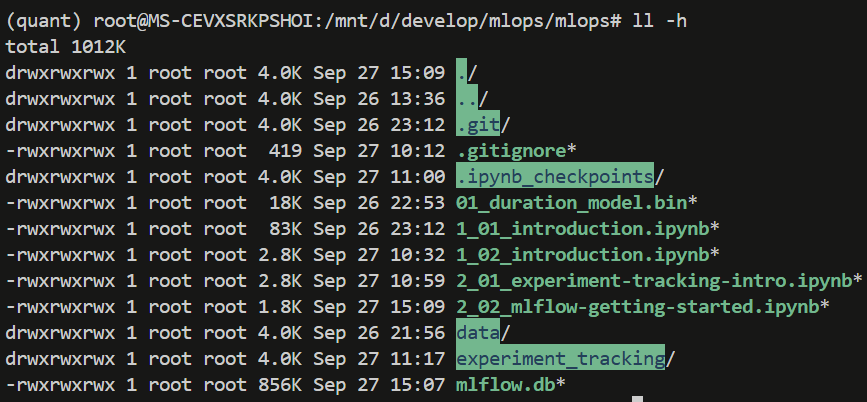

## 简单来说，它能解决你手动管理实验的麻烦。
### 以前你可能需要在笔记本里手记 alpha 和 RMSE，现在这些信息会自动保存在 mlflow.db 里，通过 mlflow ui 就能在一个可视化界面里清晰对比所有实验。
### 它支持 Python、R、Java 等多种语言，并且能和 scikit-learn、XGBoost 等主流库无缝集成

## 接下来使用mlflow


In [7]:
!python --version

Python 3.11.15


In [2]:
import pandas as pd

In [3]:
import pickle

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.metrics import root_mean_squared_error

In [6]:
# - 告诉 MLflow 把实验数据存到哪里、这次实验叫什么名字。
import mlflow
mlflow.set_tracking_uri('sqlite:///mlflow.db')
mlflow.set_experiment('nyc-taxi-experiment')

<Experiment: artifact_location='/mnt/d/develop/mlops/mlops/mlruns/1', creation_time=1790558381180, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1790558381180, lifecycle_stage='active', name='nyc-taxi-experiment', tags={}, trace_location=None, workspace='default'>

## 训练模型

In [7]:
# 把之前1_01 中的数据处理函数拿过来
def read_dataframe(filename):
    if filename.endswith('.csv'):
        df = pd.read_csv(filename)
        df.tpep_dropoff_datetime = pd.to_datetime(df.tpep_dropoff_datetime)
        df.tpep_pickup_datetime = pd.to_datetime(df.tpep_pickup_datetime)
    elif filename.endswith('.parquet'):
        df = pd.read_parquet(filename)

    df['duration'] = df.tpep_dropoff_datetime - df.tpep_pickup_datetime
    df.duration = df.duration.dt.total_seconds() / 60

    df = df[(df.duration >= 1) & (df.duration <= 60)]

    categorical = ['PULocationID', 'DOLocationID']
    numerical = ['trip_distance']
    df[categorical] = df[categorical].astype(str)
    
    return df

In [8]:
df_train = read_dataframe('./data/yellow_tripdata_2021-01.parquet')
df_val = read_dataframe('./data/yellow_tripdata_2021-02.parquet')

In [9]:
len(df_train), len(df_val)

(1343254, 1340859)

In [10]:
categorical = ['PULocationID', 'DOLocationID']
# 把目的地，作为数值特征
numerical = ['trip_distance']

In [11]:
print(df_train[['PULocationID', 'DOLocationID']].dtypes)

PULocationID    str
DOLocationID    str
dtype: object


In [12]:
train_dicts = df_train[categorical + numerical].to_dict(orient='records')

In [13]:
dv = DictVectorizer()

In [14]:
X_train = dv.fit_transform(train_dicts)

In [15]:
y_train = df_train['duration'].values

In [16]:
val_dicts = df_val[categorical + numerical].to_dict(orient='records')

In [17]:
X_val = dv.transform(val_dicts)

In [18]:
y_val = df_val['duration'].values

In [19]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_val)

root_mean_squared_error(y_val, y_pred)

7.428631092847934

## 先创建models目录

In [19]:
# 保存模型，先创建models目录
with open('models/lin_reg.bin', 'wb') as f_out:
    pickle.dump((dv, lr), f_out)

## 用 MLflow 记录一次完整的机器学习实验

In [19]:
with mlflow.start_run(): #开始一次 MLflow 运行（Run）,所有 log_* 记录的内容都会归到这次运行里。

    mlflow.set_tag("developer", "zhf") #给这次运行打一个标签：开发者是 zhf。标签用来分类、筛选实验，比如以后可以按开发者过滤。
    mlflow.set_tag("model", "lasso") #developer  和 model 都是键，第二个参数是value

    
    mlflow.log_param("train-data-path", "./data/yellow_tripdata_2021-01.parquet") #记录训练集和验证集的路径。
    mlflow.log_param("valid-data-path", "./data/yellow_tripdata_2021-02.parquet")

    alpha = 0.1
    mlflow.log_param("alpha", alpha) #定义超参数 alpha=0.1，并记录下来。以后对比不同 alpha 的实验时，一眼就能看到。
    lr = Lasso(alpha) #用这个 alpha 创建 Lasso 模型，并在训练集上训练。
    lr.fit(X_train, y_train)

    y_pred = lr.predict(X_val)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse) #记录指标

    # 3. 保存模型到本地
    with open("models/lin_reg.bin", "wb") as f_out:
        pickle.dump((dv, lr), f_out)
    # 4. 把本地已经存在的文件上传到 MLflow，存起来。
    mlflow.log_artifact(local_path="models/lin_reg.bin", artifact_path="models_pickle")
    # local_path	本地文件路径 ； artifact_path	在 MLflow 里的存放目录

## 使用梯度提升模型，进行训练
### 用 Hyperopt 自动搜索 XGBoost 的最佳超参数，每次搜索都记录到 MLflow。

In [20]:
import xgboost as xgb

In [21]:
print(xgb.__version__)

3.2.0


In [22]:
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials
from hyperopt.pyll import scope

In [23]:
#CPU训练，使用的代码
#train = xgb.DMatrix(X_train, label=y_train)
#valid = xgb.DMatrix(X_val, label=y_val)
# 对GPU训练，更好的代码方式
train = xgb.QuantileDMatrix(X_train, label=y_train)
valid = xgb.QuantileDMatrix(X_val, label=y_val, ref=train)

In [23]:
def objective(params):# 这是 Hyperopt 要优化的目标函数。给它一组超参数，它返回一个 loss。
    with mlflow.start_run():  # 每次试验开一个 MLflow run
        mlflow.set_tag("developer", "zhf")
        mlflow.set_tag("model", "xgboost")
        mlflow.log_params(params) #记录参数（Parameters），也就是训练前设定的超参数。
        xgb_model = xgb.train(    # 用这组参数训练 XGBoost
            params=params,
            dtrain=train,
            num_boost_round=500,  #最多训练500棵树，每加1棵树，就算训练1轮，就在 valid 上算一次误差。
            evals=[(valid, 'validation')],#指定评估集。每训练一轮，就在valid这个验证集上算一次误差，用来监控训练效果。'validation' 是给这个评估集起的名字，日志里会显示。
            early_stopping_rounds=50   # 如果验证集 50 轮没改善，就提前停，不再增加树的数量，省时间。
        )
        y_pred = xgb_model.predict(valid)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)  # 把 rmse 这个值记录到 MLflow

    return {'loss': rmse, 'status': STATUS_OK}

In [ ]:
#超参数的取值范围字典，Hyperopt 从里面采样具体参数去训练。
search_space = { 
    'device': 'cuda',        # XGBoost 2.0+ 可以使用，
    'tree_method': 'hist',   # 配合 device='cuda' 使用
    # hp.quniform  均匀分布
    'max_depth': scope.int(hp.quniform('max_depth', 3, 10, 1)),
    'learning_rate': hp.loguniform('learning_rate', -3, 0),
    'reg_alpha': hp.loguniform('reg_alpha', -5, -1),   #L1 正则化
    'reg_lambda': hp.loguniform('reg_lambda', -6, -1),  # L2 正则化
    'min_child_weight': hp.loguniform('min_child_weight', -1, 3),
    'objective': 'reg:squarederror',
    'seed': 42
}

# 调度器，执行超参数搜索，调用objective(params)，训练XGBoost
best_result = fmin(
    fn=objective,   # 要优化的函数
    space=search_space,  
    algo=tpe.suggest,  # 用 TPE 算法决定下一组参数
    max_evals=20,  # 最多试 20 组超参数
    trials=Trials()  # 记录所有试验结果
)

[0]	validation-rmse:5.39576                                                                         
[1]	validation-rmse:5.09528                                                                         
[2]	validation-rmse:5.03856                                                                         
[3]	validation-rmse:4.97675                                                                         
[4]	validation-rmse:4.92581                                                                         
[5]	validation-rmse:4.90045                                                                         
[6]	validation-rmse:4.83530                                                                         
[7]	validation-rmse:4.82439                                                                         
[8]	validation-rmse:4.81293                                                                         
[9]	validation-rmse:4.80394                                                                

In [24]:
# 避免和手动写的 log_params、log_metric 重复或冲突。
# 关闭 MLflow 对 XGBoost 的自动日志记录。
mlflow.xgboost.autolog(disable=True)   

In [30]:
print("最佳参数:", best_result)

最佳参数: {'learning_rate': np.float64(0.6858740958044267), 'max_depth': np.float64(8.0), 'min_child_weight': np.float64(3.3997240711207373), 'reg_alpha': np.float64(0.007605480572727215), 'reg_lambda': np.float64(0.028182912944966408)}


## 使用最佳超参数，重新训练一次，获得最优模型

In [25]:

with mlflow.start_run():
    
    train = xgb.DMatrix(X_train, label=y_train)
    valid = xgb.DMatrix(X_val, label=y_val)

    best_params = {
        'learning_rate': 0.6858740958044267,
        'max_depth': 8,
        'min_child_weight': 3.3997240711207373,
        'objective': 'reg:squarederror',
        'reg_alpha':0.007605480572727215,
        'reg_lambda': 0.028182912944966408,
        'seed': 42
    }

    mlflow.log_params(best_params)

    booster = xgb.train(
        params=best_params,
        dtrain=train,
        num_boost_round=1000,
        evals=[(valid, 'validation')],
        early_stopping_rounds=50
    )

    y_pred = booster.predict(valid)
    rmse = root_mean_squared_error(y_val, y_pred)
    mlflow.log_metric("rmse", rmse)

    with open("models/preprocessor.b", "wb") as f_out:
        pickle.dump(dv, f_out)
    mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor") # 上传一个预处理文件。

    mlflow.xgboost.log_model(booster, artifact_path="models_mlflow",registered_model_name="nyc-taxi-xgboost") 
    #不但上传模型文件到 Run 的 Artifacts，还自动在 Models  Registry（模型注册表）里登记一条记录。
    #保存 XGBoost 模型，用 MLflow 的专用格式。放在：mlruns/ 是 MLflow 默认的本地存储目录

[0]	validation-rmse:5.47495
[1]	validation-rmse:4.83564
[2]	validation-rmse:4.72374
[3]	validation-rmse:4.68038
[4]	validation-rmse:4.66273
[5]	validation-rmse:4.64968
[6]	validation-rmse:4.63942
[7]	validation-rmse:4.62838
[8]	validation-rmse:4.62026
[9]	validation-rmse:4.61383
[10]	validation-rmse:4.59254
[11]	validation-rmse:4.58333
[12]	validation-rmse:4.57653
[13]	validation-rmse:4.56853
[14]	validation-rmse:4.56405
[15]	validation-rmse:4.55891
[16]	validation-rmse:4.55532
[17]	validation-rmse:4.55048
[18]	validation-rmse:4.54483
[19]	validation-rmse:4.54213
[20]	validation-rmse:4.53835
[21]	validation-rmse:4.53465
[22]	validation-rmse:4.52614
[23]	validation-rmse:4.52361
[24]	validation-rmse:4.52077
[25]	validation-rmse:4.51136
[26]	validation-rmse:4.50643
[27]	validation-rmse:4.50501
[28]	validation-rmse:4.50330
[29]	validation-rmse:4.50124
[30]	validation-rmse:4.49571
[31]	validation-rmse:4.49275
[32]	validation-rmse:4.48595
[33]	validation-rmse:4.48452
[34]	validation-rmse:4.4

2026/09/28 21:30:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
Successfully registered model 'nyc-taxi-xgboost'.
Created version '1' of model 'nyc-taxi-xgboost'.


## 用默认参数依次训练 4 种模型，每个都记到 MLflow，最后对比 RMSE 选最好的。

In [ ]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.svm import LinearSVR


for model_class in (RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor, LinearSVR):

    with mlflow.start_run():

        mlflow.log_param("train-data-path", "./data/yellow_tripdata_2021-01.parquet")
        mlflow.log_param("valid-data-path", "./data/yellow_tripdata_2021-02.parquet")
        mlflow.log_artifact("models/preprocessor.b", artifact_path="preprocessor")
        # 没 dv，模型用不了，dv 必须和模型绑在同一个 Run 里

        
        mlmodel = model_class()
        mlmodel.fit(X_train, y_train)

        y_pred = mlmodel.predict(X_val)
        rmse = root_mean_squared_error(y_val, y_pred)
        mlflow.log_metric("rmse", rmse)

## 这四个模型不跑了，数据量太大，默认的参数都很宽泛，太费力了。知道意思就行了。